## Load the dataset

In [25]:
from pathlib import Path

import pandas as pd

import geopandas as gpd

In [2]:
# Find the project root regardless of whether the notebook
# starts from the root folder or the notebooks folder.
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = (
    project_root
    / "data"
    / "raw"
    / "fires"
    / "nfdb_point_2026"
    / "NFDB_point_20260527.txt"
)

print("Project root:", project_root)
print("Dataset found:", data_path.exists())

Project root: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence
Dataset found: True


In [3]:
fires = pd.read_csv(
    data_path,
    skipinitialspace=True,
    na_values=["", " "],
    low_memory=False,
)

print("Rows and columns:", fires.shape)
fires.head()

Rows and columns: (448602, 24)


,NFDBFIREID,SRC_AGENCY,NAT_PARK,FIRE_ID,FIRENAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,...,CAUSE22,CCAUSE,FIRE_TYPE,RESPONSE,PROTZONE,PRESCRIBED,MORE_INFO,CFS_NOTE1,CFS_NOTE2,ACQ_DATE
0,AB-2024-CWF-001-2024,AB,NaN,CWF-001-2024,NaN,50.066333,-114.154883,2024,1,2,...,H,H,Wildfire,NaN,NaN,NaN,Calgary Forest Area,NaN,NaN,2025-04-07 00:00:00
1,AB-2024-HWF-001-2024,AB,NaN,HWF-001-2024,NaN,57.912833,-116.334050,2024,1,5,...,H,H,Wildfire,NaN,NaN,NaN,High Level Forest Area,NaN,NaN,2025-04-07 00:00:00
2,AB-2024-SWF-001-2024,AB,NaN,SWF-001-2024,NaN,56.575550,-115.216533,2024,1,17,...,H,H,Wildfire,NaN,NaN,NaN,Slave Lake Forest Area,NaN,NaN,2025-04-07 00:00:00
3,AB-2024-LWF-001-2024,AB,NaN,LWF-001-2024,NaN,55.957361,-110.709667,2024,1,9,...,H,H,Wildfire,NaN,NaN,NaN,Lac La Biche Forest Area,NaN,NaN,2025-04-07 00:00:00
4,AB-2024-LWF-002-2024,AB,NaN,LWF-002-2024,NaN,55.957361,-110.709667,2024,1,9,...,H,H,Wildfire,NaN,NaN,NaN,Lac La Biche Forest Area,NaN,NaN,2025-04-07 00:00:00


## Inspect the columns

In [4]:
fires.info()

<class 'pandas.DataFrame'>
RangeIndex: 448602 entries, 0 to 448601
Data columns (total 24 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   NFDBFIREID  448602 non-null  str    
 1   SRC_AGENCY  448602 non-null  str    
 2   NAT_PARK    4488 non-null    str    
 3   FIRE_ID     448437 non-null  str    
 4   FIRENAME    68983 non-null   str    
 5   LATITUDE    448602 non-null  float64
 6   LONGITUDE   448602 non-null  float64
 7   YEAR        448602 non-null  int64  
 8   MONTH       448602 non-null  int64  
 9   DAY         448602 non-null  int64  
 10  REP_DATE    444555 non-null  str    
 11  ATTK_DATE   926 non-null     str    
 12  OUT_DATE    232001 non-null  str    
 13  SIZE_HA     448602 non-null  float64
 14  CAUSE22     448602 non-null  str    
 15  CCAUSE      448602 non-null  str    
 16  FIRE_TYPE   303115 non-null  str    
 17  RESPONSE    67132 non-null   str    
 18  PROTZONE    80690 non-null   str    
 19  PRESCRIBED  1

In [5]:
fires.columns.tolist()

['NFDBFIREID',
 'SRC_AGENCY',
 'NAT_PARK',
 'FIRE_ID',
 'FIRENAME',
 'LATITUDE',
 'LONGITUDE',
 'YEAR',
 'MONTH',
 'DAY',
 'REP_DATE',
 'ATTK_DATE',
 'OUT_DATE',
 'SIZE_HA',
 'CAUSE22',
 'CCAUSE',
 'FIRE_TYPE',
 'RESPONSE',
 'PROTZONE',
 'PRESCRIBED',
 'MORE_INFO',
 'CFS_NOTE1',
 'CFS_NOTE2',
 'ACQ_DATE']

## Filter Manitoba records

In [6]:
fires["SRC_AGENCY"].value_counts().sort_index()

SRC_AGENCY
AB     67746
BC    156554
MB     28797
NB     12181
NL      4915
NS     11087
NT     15306
ON     65881
PC      4488
PE        55
QC     45363
SK     27323
YT      8906
Name: count, dtype: int64

In [7]:
mb_fires = fires.loc[fires["SRC_AGENCY"] == "MB"].copy()

print("All Canadian records:", len(fires))
print("Manitoba records:", len(mb_fires))

mb_fires.head()

All Canadian records: 448602
Manitoba records: 28797


,NFDBFIREID,SRC_AGENCY,NAT_PARK,FIRE_ID,FIRENAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,...,CAUSE22,CCAUSE,FIRE_TYPE,RESPONSE,PROTZONE,PRESCRIBED,MORE_INFO,CFS_NOTE1,CFS_NOTE2,ACQ_DATE
1273,MB-2024-EA001,MB,NaN,EA001,NaN,49.451111,-96.390000,2024,4,13,...,H,H,NaN,FUL,R,NaN,NaN,NaN,NaN,2025-03-31 00:00:00
1274,MB-2024-EA002,MB,NaN,EA002,NaN,51.583889,-98.740000,2024,4,23,...,H,H,NaN,FUL,R,NaN,NaN,NaN,NaN,2025-03-31 00:00:00
1275,MB-2024-EA003,MB,NaN,EA003,NaN,51.565556,-98.722778,2024,4,23,...,H,H,NaN,MOD,R,NaN,NaN,NaN,NaN,2025-03-31 00:00:00
1276,MB-2024-EA005,MB,NaN,EA005,NaN,51.741111,-99.802778,2024,4,25,...,H,H,NaN,FUL,R,NaN,NaN,NaN,NaN,2025-03-31 00:00:00
1277,MB-2024-EA006,MB,NaN,EA006,NaN,51.602500,-98.648611,2024,4,25,...,H,H,NaN,FUL,R,NaN,NaN,NaN,NaN,2025-03-31 00:00:00


## Manitoba checks

In [8]:
print("First year:", mb_fires["YEAR"].min())
print("Most recent year:", mb_fires["YEAR"].max())

print("Missing latitude:", mb_fires["LATITUDE"].isna().sum())
print("Missing longitude:", mb_fires["LONGITUDE"].isna().sum())
print("Missing reported date:", mb_fires["REP_DATE"].isna().sum())
print("Missing fire size:", mb_fires["SIZE_HA"].isna().sum())

First year: 1959
Most recent year: 2025
Missing latitude: 0
Missing longitude: 0
Missing reported date: 2857
Missing fire size: 0


## Inspect the date components

In [9]:
date_columns = ["REP_DATE", "YEAR", "MONTH", "DAY"]

mb_fires[date_columns].isna().sum()

REP_DATE    2857
YEAR           0
MONTH          0
DAY            0
dtype: int64

In [10]:
mb_fires.loc[
    mb_fires["REP_DATE"].isna(),
    ["NFDBFIREID", "YEAR", "MONTH", "DAY", "REP_DATE"]
].head(10)

,NFDBFIREID,YEAR,MONTH,DAY,REP_DATE
274208,MB-1998-NE-105-257-98,1998,0,0,NaN
274209,MB-1998-NE-105-259-98,1998,0,0,NaN
274256,MB-1998-NE-109-256-98,1998,0,0,NaN
274257,MB-1998-NE-105-252-98,1998,0,0,NaN
274290,MB-1998-NE-105-254-98,1998,0,0,NaN
274291,MB-1998-NE-105-255-98,1998,0,0,NaN
274554,MB-1997-NE-105-077-97,1997,0,0,NaN
274615,MB-1998-NE-101-258-98,1998,0,0,NaN
274616,MB-1998-NE-102-253-98,1998,0,0,NaN
274729,MB-1996-NE-102-137-96,1996,0,0,NaN


## Create one reliable fire-date column

In [11]:
# Convert the reported date to a proper datetime.
reported_date = pd.to_datetime(
    mb_fires["REP_DATE"],
    errors="coerce"
)

# Reconstruct dates from the separate year, month, and day columns.
date_from_components = pd.to_datetime(
    {
        "year": mb_fires["YEAR"],
        "month": mb_fires["MONTH"],
        "day": mb_fires["DAY"],
    },
    errors="coerce",
)

# Prefer REP_DATE, but use YEAR/MONTH/DAY when REP_DATE is missing.
mb_fires["FIRE_DATE"] = reported_date.fillna(date_from_components)

print("Missing original REP_DATE:", reported_date.isna().sum())
print("Missing final FIRE_DATE:", mb_fires["FIRE_DATE"].isna().sum())

Missing original REP_DATE: 2857
Missing final FIRE_DATE: 2857


In [12]:
fires_by_year = (
    mb_fires.groupby("YEAR")
    .size()
    .rename("fire_count")
)

fires_by_year.tail(15)

YEAR
2011    315
2012    497
2013    494
2014    245
2015    459
2016    202
2017    557
2018    476
2019    278
2020    151
2021    494
2022    224
2023    300
2024    321
2025    444
Name: fire_count, dtype: int64

In [13]:
print("Total Manitoba records:", len(mb_fires))
print("Missing final FIRE_DATE:", mb_fires["FIRE_DATE"].isna().sum())
print("Earliest FIRE_DATE:", mb_fires["FIRE_DATE"].min())
print("Latest FIRE_DATE:", mb_fires["FIRE_DATE"].max())

print("\nRecent yearly fire counts:")
display(fires_by_year.tail(15).to_frame())

print("\n2025 records by month:")
display(
    mb_fires.loc[mb_fires["YEAR"] == 2025]
    .groupby("MONTH")
    .size()
    .rename("fire_count")
    .to_frame()
)

Total Manitoba records: 28797
Missing final FIRE_DATE: 2857
Earliest FIRE_DATE: 1959-05-21 00:00:00
Latest FIRE_DATE: 2025-10-23 00:00:00

Recent yearly fire counts:


,fire_count
YEAR,
2011,315
2012,497
2013,494
2014,245
2015,459
2016,202
2017,557
2018,476
2019,278



2025 records by month:


,fire_count
MONTH,
4,40
5,67
6,75
7,189
8,59
9,13
10,1


In [14]:
missing_date_rows = mb_fires.loc[mb_fires["FIRE_DATE"].isna()].copy()

print("Records without an exact fire date:", len(missing_date_rows))

display(
    missing_date_rows[
        ["YEAR", "MONTH", "DAY", "REP_DATE", "ATTK_DATE", "OUT_DATE"]
    ].isna().sum().to_frame("missing_count")
)

display(
    missing_date_rows[
        [
            "NFDBFIREID",
            "YEAR",
            "MONTH",
            "DAY",
            "REP_DATE",
            "ATTK_DATE",
            "OUT_DATE",
        ]
    ].head(10)
)

Records without an exact fire date: 2857


,missing_count
YEAR,0
MONTH,0
DAY,0
REP_DATE,2857
ATTK_DATE,2857
OUT_DATE,2845


,NFDBFIREID,YEAR,MONTH,DAY,REP_DATE,ATTK_DATE,OUT_DATE
274208,MB-1998-NE-105-257-98,1998,0,0,NaN,NaN,1998-11-05 00:00:00
274209,MB-1998-NE-105-259-98,1998,0,0,NaN,NaN,1998-12-08 00:00:00
274256,MB-1998-NE-109-256-98,1998,0,0,NaN,NaN,1998-11-04 00:00:00
274257,MB-1998-NE-105-252-98,1998,0,0,NaN,NaN,1998-11-05 00:00:00
274290,MB-1998-NE-105-254-98,1998,0,0,NaN,NaN,1998-11-04 00:00:00
274291,MB-1998-NE-105-255-98,1998,0,0,NaN,NaN,1998-11-04 00:00:00
274554,MB-1997-NE-105-077-97,1997,0,0,NaN,NaN,1997-07-18 00:00:00
274615,MB-1998-NE-101-258-98,1998,0,0,NaN,NaN,1998-11-05 00:00:00
274616,MB-1998-NE-102-253-98,1998,0,0,NaN,NaN,1998-11-05 00:00:00
274729,MB-1996-NE-102-137-96,1996,0,0,NaN,NaN,1996-07-29 00:00:00


In [15]:
missing_dates_by_year = (
    missing_date_rows.groupby("YEAR")
    .size()
    .rename("missing_exact_dates")
)

display(missing_dates_by_year.to_frame())

,missing_exact_dates
YEAR,
1996,2
1997,1
1998,9
2000,353
2001,527
2002,755
2003,1207
2004,3


In [16]:
attack_date = pd.to_datetime(
    mb_fires["ATTK_DATE"],
    errors="coerce",
)

mb_fires["FIRE_DATE_REVISED"] = (
    reported_date
    .fillna(attack_date)
    .fillna(date_from_components)
)

print(
    "Missing dates after including ATTK_DATE:",
    mb_fires["FIRE_DATE_REVISED"].isna().sum(),
)

Missing dates after including ATTK_DATE: 2857


In [17]:
missing_date_mask = mb_fires["FIRE_DATE_REVISED"].isna()

missing_date_summary = (
    mb_fires
    .assign(missing_exact_date=missing_date_mask)
    .groupby("YEAR")
    .agg(
        total_fires=("NFDBFIREID", "size"),
        missing_exact_dates=("missing_exact_date", "sum"),
    )
)

missing_date_summary["missing_percent"] = (
    missing_date_summary["missing_exact_dates"]
    / missing_date_summary["total_fires"]
    * 100
).round(1)

display(
    missing_date_summary.loc[
        missing_date_summary["missing_exact_dates"] > 0
    ]
)

,total_fires,missing_exact_dates,missing_percent
YEAR,,,
1996,424,2,0.5
1997,373,1,0.3
1998,516,9,1.7
2000,353,353,100.0
2001,527,527,100.0
2002,755,755,100.0
2003,1207,1207,100.0
2004,55,3,5.5


In [18]:
mb_fires_dated = (
    mb_fires.loc[mb_fires["FIRE_DATE_REVISED"].notna()]
    .copy()
)

mb_fires_dated["FIRE_DATE"] = mb_fires_dated["FIRE_DATE_REVISED"]

print("Daily-analysis records:", len(mb_fires_dated))

Daily-analysis records: 25940


In [19]:
MODEL_START_YEAR = 2005
MODEL_END_YEAR = 2025

mb_model_fires = (
    mb_fires_dated.loc[
        mb_fires_dated["YEAR"].between(
            MODEL_START_YEAR,
            MODEL_END_YEAR,
        )
    ]
    .copy()
)

mb_model_fires["FIRE_DATE"] = pd.to_datetime(
    mb_model_fires["FIRE_DATE"]
).dt.normalize()

print("Model period:", MODEL_START_YEAR, "to", MODEL_END_YEAR)
print("Records available:", len(mb_model_fires))
print("Earliest date:", mb_model_fires["FIRE_DATE"].min())
print("Latest date:", mb_model_fires["FIRE_DATE"].max())

Model period: 2005 to 2025
Records available: 7933
Earliest date: 2005-04-06 00:00:00
Latest date: 2025-10-23 00:00:00


In [20]:
display(
    mb_model_fires["CAUSE22"]
    .fillna("Missing")
    .value_counts()
    .rename("fire_count")
    .to_frame()
)

,fire_count
CAUSE22,
N,4661
H,3255
U,17


In [21]:
quality_audit = {
    "Duplicate fire IDs": mb_model_fires["NFDBFIREID"].duplicated().sum(),
    "Duplicate complete rows": mb_model_fires.duplicated().sum(),
    "Zero-size fires": (mb_model_fires["SIZE_HA"] == 0).sum(),
    "Negative-size fires": (mb_model_fires["SIZE_HA"] < 0).sum(),
}

for check, result in quality_audit.items():
    print(f"{check}: {result}")

print(
    "\nLatitude range:",
    mb_model_fires["LATITUDE"].min(),
    "to",
    mb_model_fires["LATITUDE"].max(),
)

print(
    "Longitude range:",
    mb_model_fires["LONGITUDE"].min(),
    "to",
    mb_model_fires["LONGITUDE"].max(),
)

Duplicate fire IDs: 2
Duplicate complete rows: 2
Zero-size fires: 153
Negative-size fires: 0

Latitude range: 49.002778 to 59.9974236935
Longitude range: -102.11 to -89.832778


Inspect the duplicates:

In [22]:
duplicate_id_records = (
    mb_model_fires.loc[
        mb_model_fires["NFDBFIREID"].duplicated(keep=False)
    ]
    .sort_values("NFDBFIREID")
)

display(
    duplicate_id_records[
        [
            "NFDBFIREID",
            "FIRE_DATE",
            "LATITUDE",
            "LONGITUDE",
            "SIZE_HA",
            "CAUSE22",
        ]
    ]
)

,NFDBFIREID,FIRE_DATE,LATITUDE,LONGITUDE,SIZE_HA,CAUSE22
288102,MB-2021-MB2021EA136,2021-07-14,51.556666,-96.345556,497.465385,N
288437,MB-2021-MB2021EA136,2021-07-14,51.556666,-96.345556,497.465385,N
288385,MB-2021-MB2021NO031,2021-07-11,54.181663,-97.173647,3851.905911,N
288440,MB-2021-MB2021NO031,2021-07-11,54.181663,-97.173647,3851.905911,N


In [23]:
mb_model_fires_clean = (
    mb_model_fires
    .drop_duplicates()
    .copy()
)

mb_model_fires_clean["ZERO_SIZE_FLAG"] = (
    mb_model_fires_clean["SIZE_HA"] == 0
)

print("Before removing exact duplicates:", len(mb_model_fires))
print("After removing exact duplicates:", len(mb_model_fires_clean))
print("Zero-size fires retained:", mb_model_fires_clean["ZERO_SIZE_FLAG"].sum())

Before removing exact duplicates: 7933
After removing exact duplicates: 7931
Zero-size fires retained: 153


## Create a GeoDataFrame

In [26]:
mb_fires_gdf = gpd.GeoDataFrame(
    mb_model_fires_clean,
    geometry=gpd.points_from_xy(
        mb_model_fires_clean["LONGITUDE"],
        mb_model_fires_clean["LATITUDE"],
    ),
    crs="EPSG:4326",
)

print(mb_fires_gdf.crs)
print(mb_fires_gdf.shape)

mb_fires_gdf[
    ["NFDBFIREID", "FIRE_DATE", "LATITUDE", "LONGITUDE", "geometry"]
].head()

EPSG:4326
(7931, 28)


,NFDBFIREID,FIRE_DATE,LATITUDE,LONGITUDE,geometry
1273,MB-2024-EA001,2024-04-13,49.451111,-96.390000,POINT (-96.39 49.45111)
1274,MB-2024-EA002,2024-04-23,51.583889,-98.740000,POINT (-98.74 51.58389)
1275,MB-2024-EA003,2024-04-23,51.565556,-98.722778,POINT (-98.72278 51.56556)
1276,MB-2024-EA005,2024-04-25,51.741111,-99.802778,POINT (-99.80278 51.74111)
1277,MB-2024-EA006,2024-04-25,51.602500,-98.648611,POINT (-98.64861 51.6025)


## Add readable cause labels

In [27]:
cause_labels = {
    "N": "Natural",
    "H": "Human",
    "U": "Unknown",
}

mb_fires_gdf["CAUSE_LABEL"] = (
    mb_fires_gdf["CAUSE22"]
    .map(cause_labels)
    .fillna("Missing")
)

mb_fires_gdf["CAUSE_LABEL"].value_counts()

CAUSE_LABEL
Natural    4659
Human      3255
Unknown      17
Name: count, dtype: int64

## Create the first wildfire map

Matplotlib is building the font cache; this may take a moment.


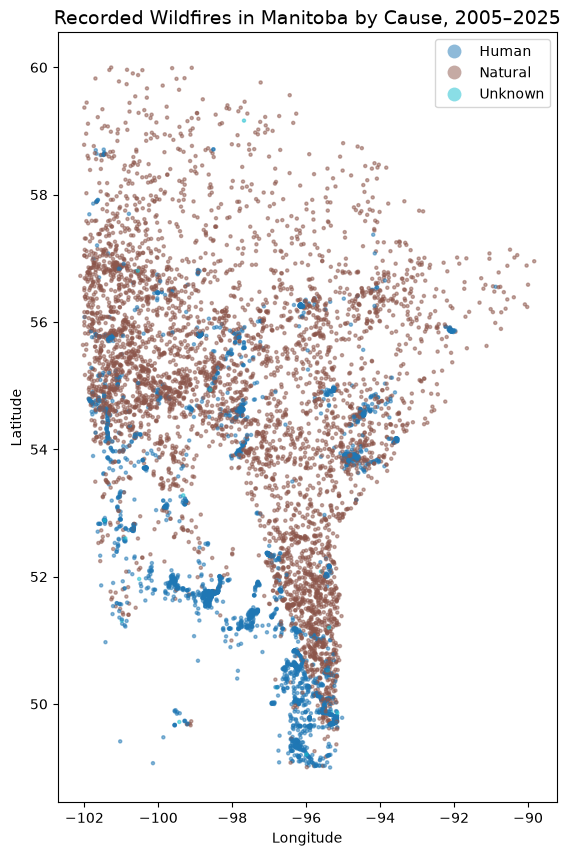

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

mb_fires_gdf.plot(
    ax=ax,
    column="CAUSE_LABEL",
    categorical=True,
    legend=True,
    markersize=5,
    alpha=0.5,
)

ax.set_title(
    "Recorded Wildfires in Manitoba by Cause, 2005–2025",
    fontsize=14,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

## Create a projected version

In [29]:
mb_fires_projected = mb_fires_gdf.to_crs("EPSG:3347")

print("Geographic CRS:", mb_fires_gdf.crs)
print("Projected CRS:", mb_fires_projected.crs)

Geographic CRS: EPSG:4326
Projected CRS: EPSG:3347


In [30]:
output_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_fires_2005_2025.parquet"
)

mb_fires_gdf.to_parquet(output_path, index=False)

print("Saved to:", output_path)
print("File exists:", output_path.exists())

Saved to: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/data/interim/manitoba_fires_2005_2025.parquet
File exists: True


GeoParquet preserves the columns, data types, coordinate system, and point geometry.

## Load MB boundary

In [31]:
boundary_path = (
    project_root
    / "data"
    / "raw"
    / "boundaries"
    / "manitoba_provincial_boundary.geojson"
)

manitoba_boundary = gpd.read_file(boundary_path)

print("Rows and columns:", manitoba_boundary.shape)
print("CRS:", manitoba_boundary.crs)

manitoba_boundary.head()

Rows and columns: (1, 7)
CRS: EPSG:4326


,FID,AREA,PERIMETER,NAME,Shape__Area,Shape__Length,geometry
0,1,650053445178,4.018512e+06,Manitoba,1.980213e+12,7.051045e+06,"POLYGON ((-94.80815 59.61792, -94.81044 59.617..."


## Check that all fire points fall inside Manitoba

In [32]:
fires_inside_manitoba = gpd.sjoin(
    mb_fires_gdf,
    manitoba_boundary[["geometry"]],
    how="inner",
    predicate="within",
)

print("Total wildfire points:", len(mb_fires_gdf))
print("Points inside Manitoba:", len(fires_inside_manitoba))
print(
    "Points outside boundary:",
    len(mb_fires_gdf) - len(fires_inside_manitoba),
)

Total wildfire points: 7931
Points inside Manitoba: 7915
Points outside boundary: 16


## Improved map

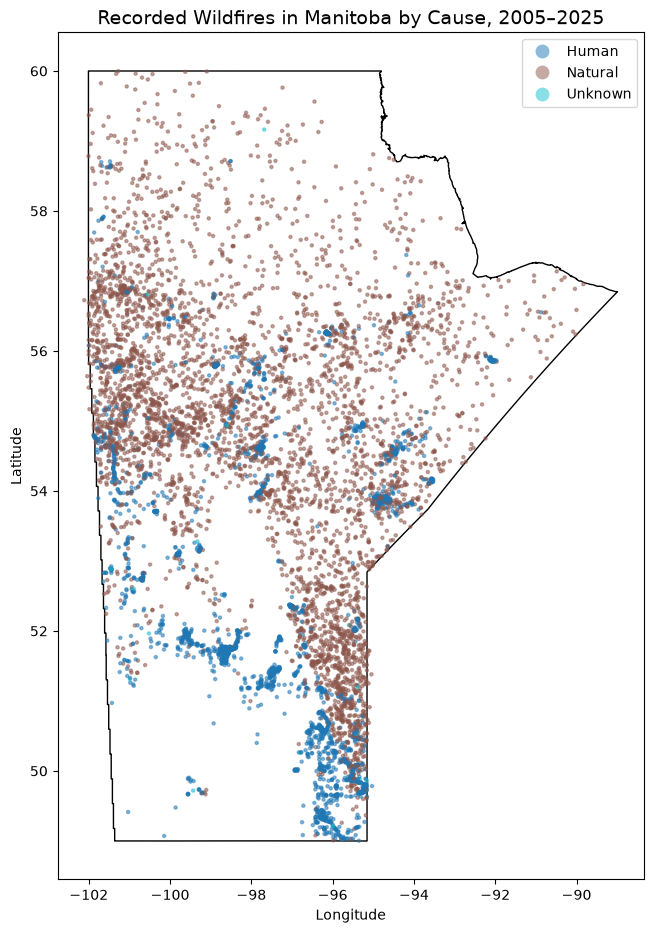

In [33]:
fig, ax = plt.subplots(figsize=(9, 11))

manitoba_boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
)

mb_fires_gdf.plot(
    ax=ax,
    column="CAUSE_LABEL",
    categorical=True,
    legend=True,
    markersize=5,
    alpha=0.5,
)

ax.set_title(
    "Recorded Wildfires in Manitoba by Cause, 2005–2025",
    fontsize=14,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [34]:
# Combine all boundary pieces into one Manitoba geometry.
manitoba_geometry = manitoba_boundary.geometry.union_all()

# "covered_by" includes points located inside or directly on the boundary.
covered_mask = mb_fires_gdf.geometry.covered_by(manitoba_geometry)

print("Points inside or on boundary:", covered_mask.sum())
print("Points still outside:", (~covered_mask).sum())

Points inside or on boundary: 7915
Points still outside: 16


In [35]:
outside_fires = mb_fires_gdf.loc[~covered_mask].copy()

display(
    outside_fires[
        [
            "NFDBFIREID",
            "FIRE_DATE",
            "LATITUDE",
            "LONGITUDE",
            "SIZE_HA",
            "CAUSE_LABEL",
        ]
    ].sort_values(["LATITUDE", "LONGITUDE"])
)

,NFDBFIREID,FIRE_DATE,LATITUDE,LONGITUDE,SIZE_HA,CAUSE_LABEL
283992,MB-2006-EA244,2006-10-08,49.783611,-95.028333,0.400000,Human
287343,MB-2014-EA026,2014-08-16,50.534444,-95.147778,0.800000,Natural
282997,MB-2006-EA119,2006-07-19,50.687500,-95.107500,0.100000,Natural
283063,MB-2011-EA087,2011-08-09,50.731111,-95.141389,0.100000,Natural
283072,MB-2011-EA124,2011-09-11,50.910277,-95.086945,1.100000,Natural
282988,MB-2006-EA084,2006-07-12,51.250000,-95.116667,1.500000,Natural
283055,MB-2011-EA070,2011-08-02,51.380555,-95.044167,0.100000,Natural
283032,MB-2007-EA066,2007-08-03,51.664167,-95.129722,0.100000,Natural
287345,MB-2014-EA029,2014-08-16,51.713611,-95.094444,0.500000,Natural
283004,MB-2006-EA163,2006-08-08,51.721111,-95.123056,0.100000,Natural


In [36]:
boundary_projected = manitoba_boundary.to_crs("EPSG:3347")
outside_projected = outside_fires.to_crs("EPSG:3347")

boundary_geometry_projected = (
    boundary_projected.geometry.union_all()
)

outside_fires["DISTANCE_FROM_MB_KM"] = (
    outside_projected.geometry
    .distance(boundary_geometry_projected)
    / 1000
)

display(
    outside_fires[
        [
            "NFDBFIREID",
            "LATITUDE",
            "LONGITUDE",
            "DISTANCE_FROM_MB_KM",
        ]
    ].sort_values("DISTANCE_FROM_MB_KM")
)

,NFDBFIREID,LATITUDE,LONGITUDE,DISTANCE_FROM_MB_KM
281855,MB-2008-NW073,54.752222,-101.851111,0.230863
1514,MB-2024-NO149,54.750000,-92.238333,0.315233
287343,MB-2014-EA026,50.534444,-95.147778,0.411833
283063,MB-2011-EA087,50.731111,-95.141389,0.859368
283032,MB-2007-EA066,51.664167,-95.129722,1.641399
283004,MB-2006-EA163,51.721111,-95.123056,2.095291
16219,MB-2023-WE050,55.476100,-102.003000,2.432417
282988,MB-2006-EA084,51.250000,-95.116667,2.562593
282997,MB-2006-EA119,50.687500,-95.107500,3.240067
284824,MB-2012-NW044,55.168056,-101.983889,3.735158


In [37]:
mb_fires_gdf["SPATIAL_STATUS"] = "Inside Manitoba"
mb_fires_gdf.loc[~covered_mask, "SPATIAL_STATUS"] = "Outside boundary"

mb_fires_gdf["SPATIAL_STATUS"].value_counts()

SPATIAL_STATUS
Inside Manitoba     7915
Outside boundary      16
Name: count, dtype: int64

In [38]:
mb_fires_spatial = (
    mb_fires_gdf.loc[covered_mask]
    .copy()
)

print("Complete historical dataset:", len(mb_fires_gdf))
print("Dataset for Manitoba grid modelling:", len(mb_fires_spatial))
print(
    "Excluded from spatial modelling:",
    len(mb_fires_gdf) - len(mb_fires_spatial),
)

Complete historical dataset: 7931
Dataset for Manitoba grid modelling: 7915
Excluded from spatial modelling: 16


In [39]:
outside_audit_path = (
    project_root
    / "data"
    / "interim"
    / "fires_outside_manitoba_boundary.csv"
)

outside_fires.drop(columns="geometry").to_csv(
    outside_audit_path,
    index=False,
)

print("Audit file saved:", outside_audit_path)

Audit file saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/data/interim/fires_outside_manitoba_boundary.csv


In [40]:
clean_output_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_fires_2005_2025_clean.parquet"
)

mb_fires_gdf.to_parquet(
    clean_output_path,
    index=False,
)

print("Clean dataset saved:", clean_output_path)

Clean dataset saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/data/interim/manitoba_fires_2005_2025_clean.parquet
